In [1]:
import os
os.listdir('.')

['.prompts',
 ' v6 — Binding Context Document.pdf',
 '.config',
 '.kernel_llm_logs_1.txt',
 'memory']

In [2]:
import mpmath as mp
import numpy as np
print(mp.__version__, np.__version__)

1.3.0 2.4.3


In [3]:

# Plan:
# 1. For T in [10^4, 10^5], compute |zeta(1/2 + i t)| on a fine grid.
# 2. Use Kahan-summed Riemann-Siegel-like; actually use mp.zeta which is high precision.
# But evaluating at N=10^6 points densely on [10^4, 10^5] would be huge.
# Re-read carefully: "Riemann zeta function at N=10^6 for large T (e.g., T∈[10^4, 10^5])".
# This means N = 10^6 sample points across T window.
# Step size dt = (10^5 - 10^4)/10^6 = 0.09.
# At T=10^4, the mean spacing of zeros is 2pi/log(T/(2pi))~ 2pi/log(1591)~ 0.85. So dt=0.09 is fine.
# 
# We need |zeta(1/2 + i*t)|. Compute at 10^6 points using mp.zeta; that may be slow.
# Use mpmath siegelz which is faster: Z(t) = exp(i*theta(t)) zeta(1/2+i t), |Z(t)|=|zeta(1/2+it)|.
# We'll use mp.siegelz with mp.dps moderate to keep speed.

# Time check first:
import time
mp.mp.dps = 15
t0 = time.time()
vals = []
for t in np.linspace(1e4, 1e4+10, 100):
 vals.append(abs(mp.siegelz(t)))
print("100 evals:", time.time()-t0, "s")
print(vals[:5])

100 evals: 4.467306613922119 s
[mpf('0.34139472423120854'), mpf('0.15205946492300615'), mpf('0.44349833810811945'), mpf('0.53587685106614336'), mpf('0.46421828643208474')]


In [4]:

# 4.5s for 100 evals at T~1e4 -> 10^6 points would take ~12 hours. Way too slow.
# Estimate scaling for higher T:
import time
mp.mp.dps = 15
t0 = time.time()
for t in np.linspace(1e5, 1e5+10, 50):
 abs(mp.siegelz(t))
print("T=1e5 50 evals:", time.time()-t0)

T=1e5 50 evals: 1.2822186946868896


In [5]:

# Faster at high T (~25ms each). Average ~30-40ms. 1e6 points -> ~10 hours. Still too slow.
#
# Strategy: do this analysis in TWO logarithmically-distributed T regions, but use a smaller N.
# But the research objective specifies N=10^6.
# 
# Alternatively, evaluate Riemann-Siegel formula with Kahan summation (R6) at moderate dps.
# We can implement the main sum ourselves with vectorized numpy: 
# Z(t) = 2 * sum_{n=1}^{N(t)} cos(theta(t) - t log n)/sqrt(n) + remainder
# where N(t) = floor(sqrt(t/(2pi))). This is O(sqrt(t)) per evaluation.
# For t ~ 1e5, sqrt(t/(2pi)) ~ 126 terms. 1e6 evals * 126 ops = 1.26e8 - very fast vectorized.
# 
# Implement Riemann-Siegel main sum with high precision Kahan summation.

# theta(t) = arg(Gamma(1/4 + i t/2)) - (t/2)*log(pi)
# Use mpmath for theta (fast scalar function), then numpy for the main sum vectorization across t.

# Actually compute theta(t) array using mpmath for each t (slow). 
# Instead use asymptotic theta(t) ≈ (t/2)log(t/(2pi)) - t/2 - pi/8 + 1/(48 t) + 7/(5760 t^3) ...
# This is very accurate for t > 1e4.

import numpy as np

def theta_asym(t):
 # Riemann-Siegel theta asymptotic
 return (t/2.0)*np.log(t/(2.0*np.pi)) - t/2.0 - np.pi/8.0 + 1.0/(48.0*t) + 7.0/(5760.0*t**3)

# Test vs mpmath siegeltheta
for t in [1e4, 5e4, 1e5]:
 a = float(mp.siegeltheta(t))
 b = theta_asym(t)
 print(t, a, b, abs(a-b))

10000.0 31861.92383083582 31861.923830835818 3.637978807091713e-12
50000.0 199547.13775135842 199547.1377513584 2.9103830456733704e-11
100000.0 433752.0272291708 433752.0272291708 0.0


In [6]:

# Excellent. Asymptotic theta is good to ~1e-11.
# Implement Riemann-Siegel Z(t) with main sum + remainder C0 term.
# Z(t) = 2*sum_{n=1}^{m} cos(theta(t) - t log n)/sqrt(n) + R(t)
# where m = floor(sqrt(t/(2pi))).
# Remainder R(t) ~ (-1)^(m-1) (t/(2pi))^(-1/4) * Psi(p), where p = sqrt(t/(2pi)) - m, 
# Psi(p) = cos(2pi(p^2 - p - 1/16))/cos(2pi*p)
# This is the leading C0 term.

def riemann_siegel_Z_vec(t_array):
 # t_array: 1D numpy array of t values, each > 1e4
 t = t_array
 sqrt_t_over_2pi = np.sqrt(t/(2.0*np.pi))
 m = np.floor(sqrt_t_over_2pi).astype(np.int64)
 th = theta_asym(t)
 # We need to sum across n=1..m_i for each t_i. m varies but slowly.
 # Group by unique m values.
 Z = np.zeros_like(t)
 unique_m = np.unique(m)
 # For each unique m, we have a set of t's with the same m
 # Vectorize: precompute log(n) for n=1..max_m, then for each group compute the sum
 max_m = int(m.max())
 log_n = np.log(np.arange(1, max_m+1))
 inv_sqrt_n = 1.0/np.sqrt(np.arange(1, max_m+1))
 
 for mm in unique_m:
 idx = (m == mm)
 ts = t[idx]
 ths = th[idx]
 # sum_{n=1..mm} cos(theta - t log n)/sqrt(n)
 # Build (len(ts), mm) - careful with memory
 # cos(ths[:,None] - ts[:,None]*log_n[:mm][None,:]) * inv_sqrt_n[:mm][None,:]
 contrib = np.cos(ths[:,None] - ts[:,None]*log_n[:mm][None,:]) * inv_sqrt_n[:mm][None,:]
 S = 2.0 * contrib.sum(axis=1)
 # Remainder
 p = sqrt_t_over_2pi[idx] - mm
 Psi = np.cos(2.0*np.pi*(p*p - p - 1.0/16.0))/np.cos(2.0*np.pi*p)
 R = ((-1)**(mm-1)) * (t[idx]/(2.0*np.pi))**(-0.25) * Psi
 Z[idx] = S + R
 return Z

# Test on a few points
ts = np.array([1e4, 1e4+1, 5e4, 1e5])
Zs = riemann_siegel_Z_vec(ts)
for ti, zi in zip(ts, Zs):
 truth = float(mp.siegelz(ti))
 print(f"t={ti}: RS={zi:.8f} mp={truth:.8f} diff={zi-truth:.2e}")

t=10000.0: RS=-0.34138983 mp=-0.34139472 diff=4.89e-06
t=10001.0: RS=0.22671533 mp=0.22671178 diff=3.55e-06
t=50000.0: RS=2.97003134 mp=2.97004334 diff=-1.20e-05
t=100000.0: RS=5.87959778 mp=5.87959247 diff=5.31e-06


In [7]:

# Accuracy ~1e-5, sufficient for GEV analysis of |zeta|. Good.
# Now compute |zeta(1/2 + it)| at N=10^6 points across T in [1e4, 1e5].
# Memory check: max m ~ sqrt(1e5/(2pi)) ~ 126. 1e6 t-values * 126 cols = 1.26e8 floats = 1GB.
# Need to chunk.

import time
import numpy as np

def compute_abs_zeta(T_low, T_high, N, chunk_size=20000):
 t_grid = np.linspace(T_low, T_high, N)
 Z = np.empty(N)
 n_chunks = (N + chunk_size - 1)//chunk_size
 t0 = time.time()
 for i in range(n_chunks):
 a = i*chunk_size
 b = min((i+1)*chunk_size, N)
 Z[a:b] = riemann_siegel_Z_vec(t_grid[a:b])
 if i % 10 == 0:
 print(f"chunk {i+1}/{n_chunks}, elapsed {time.time()-t0:.1f}s")
 return t_grid, np.abs(Z)

t_grid, absZ = compute_abs_zeta(1e4, 1e5, 1_000_000, chunk_size=10000)
print("done, total time", "elapsed")
print("max |zeta|:", absZ.max(), " mean:", absZ.mean())

chunk 1/100, elapsed 0.0s
chunk 11/100, elapsed 0.2s


chunk 21/100, elapsed 0.4s


chunk 31/100, elapsed 0.6s


chunk 41/100, elapsed 0.9s


chunk 51/100, elapsed 1.2s


chunk 61/100, elapsed 1.7s


chunk 71/100, elapsed 2.3s


chunk 81/100, elapsed 2.8s


chunk 91/100, elapsed 3.4s


done, total time elapsed
max |zeta|: 28.058754141752075 mean: 1.990498763634635


In [8]:

# Great. ~4 seconds. Now perform block-maxima GEV analysis with two block sizes.
# 
# Block size A: 2π/log(N) where N = 10^6 -> b_A = 2π/log(10^6)
# Block size B: 2π/log(T) -> at T~1e4 to 1e5, log T varies from ~9.21 to ~11.51.
# 
# But the GEV analysis takes block maxima. The block size is in terms of t-axis distance.
# t-axis spacing dt = (1e5 - 1e4)/1e6 = 0.09.
# 
# Block size A: 2π/log(10^6) ≈ 6.2832/13.8155 ≈ 0.4548 -> samples per block = 0.4548/0.09 ≈ 5.05
# Block size B: 2π/log(T). For T=1e4, b = 2π/log(1e4) ≈ 6.2832/9.2103 = 0.6822 -> samples ~ 7.58
# For T=1e5, b = 2π/log(1e5) ≈ 6.2832/11.5129 = 0.5458 -> samples ~ 6.06
# 
# For approach A use a constant block size = 2π/log(N), constant samples-per-block.
# For approach B the block size is 2π/log(T), local. Two natural implementations:
# B1: Use a single value at midpoint or average T, e.g., T_mid = sqrt(1e4 * 1e5) (geometric mean).
# Or use T = T_high = 1e5 (the upper end). The problem statement says "block size of 2π/log(T)".
# Convention in literature (Selberg mean spacing at height T) means at the height T of the window.
# B2: Use locally varying block sizes.
# 
# I'll implement Approach B with the representative T as the geometric mean of the window.
# This is standard and matches "Selberg mean spacing of large values at height T".
# I'll also report the result if T is taken as the upper end.

import math
N = 10**6
T_low, T_high = 1e4, 1e5
T_geom = math.sqrt(T_low*T_high) # ~31623
T_upper = T_high

dt = (T_high - T_low)/N

bA = 2*math.pi/math.log(N) # 0.4548
bB_geom = 2*math.pi/math.log(T_geom)
bB_upper = 2*math.pi/math.log(T_upper)
bB_lower = 2*math.pi/math.log(T_low)

samples_per_block_A = bA/dt
samples_per_block_B_geom = bB_geom/dt
samples_per_block_B_upper = bB_upper/dt
samples_per_block_B_lower = bB_lower/dt

print(f"dt = {dt}")
print(f"Block size A = 2π/log(N) = {bA:.6f}, samples/block = {samples_per_block_A:.3f}")
print(f"Block size B (T_geom={T_geom:.1f}) = {bB_geom:.6f}, samples/block = {samples_per_block_B_geom:.3f}")
print(f"Block size B (T_upper) = {bB_upper:.6f}, samples/block = {samples_per_block_B_upper:.3f}")
print(f"Block size B (T_lower) = {bB_lower:.6f}, samples/block = {samples_per_block_B_lower:.3f}")

dt = 0.09
Block size A = 2π/log(N) = 0.454792, samples/block = 5.053
Block size B (T_geom=31622.8) = 0.606389, samples/block = 6.738
Block size B (T_upper) = 0.545751, samples/block = 6.064
Block size B (T_lower) = 0.682188, samples/block = 7.580


In [9]:

# Block sizes are tiny (5–7 samples). With samples spacing dt=0.09, that's quite small for max-by-block.
# But this is what's prescribed. The block-maxima distribution should still be well-defined 
# given the underlying continuous |zeta|.
# 
# Use integer samples per block. We round to integer samples per block.
# Actually a more careful approach: compute the maximum within each block defined on the t-axis.
# We define block boundaries as t_0 + k*b for k=0,1,...

def block_maxima(t_grid, vals, block_size):
 # Bin values by block index = floor((t - t0)/block_size)
 t0 = t_grid[0]
 block_idx = ((t_grid - t0) / block_size).astype(np.int64)
 n_blocks = block_idx.max() + 1
 # take maximum per block via np.maximum.reduceat or pandas groupby
 # use np.bincount-like: find max per bin
 # Sort by block_idx (t_grid is sorted, so block_idx is non-decreasing)
 # Use np.maximum.reduceat: need indices where bins start
 # block_idx is non-decreasing
 starts = np.searchsorted(block_idx, np.arange(n_blocks))
 # Append len(vals) as sentinel
 maxima = np.maximum.reduceat(vals, starts)
 # Remove last block if incomplete (its right edge exceeds the data range)
 # Last block goes from t0 + (n_blocks-1)*b to t0 + n_blocks*b, which may extend past t_grid[-1]
 last_block_end = t0 + n_blocks*block_size
 if last_block_end > t_grid[-1] + dt/2:
 maxima = maxima[:-1]
 return maxima

# Approach A: block size 2π/log(N)
M_A = block_maxima(t_grid, absZ, bA)
# Approach B: block size 2π/log(T_geom)
M_B = block_maxima(t_grid, absZ, bB_geom)

print("A:", len(M_A), "blocks, mean=", M_A.mean(), "max=", M_A.max())
print("B:", len(M_B), "blocks, mean=", M_B.mean(), "max=", M_B.max())

A: 197892 blocks, mean= 2.912375914389231 max= 28.058754141752075
B: 148419 blocks, mean= 3.1733188842507887 max= 28.058754141752075


In [10]:

# Now fit GEV to block maxima using scipy.stats.genextreme.
# Compute CIs via parametric bootstrap (refit on resampled).
from scipy.stats import genextreme
import numpy as np

def fit_gev_with_ci(maxima, n_boot=200, seed=42):
 # scipy parameterization: shape c such that xi = -c (note convention)
 c, loc, scale = genextreme.fit(maxima)
 xi_hat = -c
 rng = np.random.default_rng(seed)
 n = len(maxima)
 xi_boots = []
 for _ in range(n_boot):
 idx = rng.integers(0, n, n)
 sample = maxima[idx]
 try:
 cb, lb, sb = genextreme.fit(sample)
 xi_boots.append(-cb)
 except Exception:
 pass
 xi_boots = np.array(xi_boots)
 ci = np.percentile(xi_boots, [2.5, 97.5])
 return xi_hat, loc, scale, ci, xi_boots

import time
t0 = time.time()
xi_A, loc_A, scale_A, ci_A, boots_A = fit_gev_with_ci(M_A, n_boot=200)
print(f"A: xi={xi_A:.5f}, loc={loc_A:.5f}, scale={scale_A:.5f}, 95%CI=[{ci_A[0]:.5f}, {ci_A[1]:.5f}] ({time.time()-t0:.1f}s)")
t0 = time.time()
xi_B, loc_B, scale_B, ci_B, boots_B = fit_gev_with_ci(M_B, n_boot=200)
print(f"B: xi={xi_B:.5f}, loc={loc_B:.5f}, scale={scale_B:.5f}, 95%CI=[{ci_B[0]:.5f}, {ci_B[1]:.5f}] ({time.time()-t0:.1f}s)")

TimeoutError: Code execution timed out after 900.0 seconds

In [11]:

# scipy.genextreme.fit on 200k samples with 200 bootstraps is too slow.
# Let's check single fit time first.
import time
from scipy.stats import genextreme
import numpy as np

t0 = time.time()
c, loc, scale = genextreme.fit(M_A)
print("single fit A:", time.time()-t0, "c=", c, "loc=", loc, "scale=", scale)

single fit A: 2.6785435676574707 c= -0.4799923039229721 loc= 1.4810852126105603 scale= 1.1522391853111034


In [12]:

# Single fit is 2.7s on 200k samples. 200 bootstraps -> 540s. With B we'd run another similar.
# Total ~ 18 min. Together that exceeds 15min cell limit. Reduce bootstrap to 100 each.
# First do single fit for B:
t0 = time.time()
cB, locB, scaleB = genextreme.fit(M_B)
print("single fit B:", time.time()-t0, "c=", cB, "loc=", locB, "scale=", scaleB)
xi_A_hat = -c
xi_B_hat = -cB
print("xi_A =", xi_A_hat)
print("xi_B =", xi_B_hat)

single fit B: 1.9632995128631592 c= -0.4675762607271547 loc= 1.6669605151348819 scale= 1.2393004777261631
xi_A = 0.4799923039229721
xi_B = 0.4675762607271547


In [13]:

# Both ~0.47–0.48. Difference ~0.012. Now do bootstrap with reduced n_boot=100 each, 
# split across multiple cells if needed.
import numpy as np
import time
from scipy.stats import genextreme

rng = np.random.default_rng(42)
n_boot = 100
xi_boots_A = []
nA = len(M_A)
t0 = time.time()
for i in range(n_boot):
 idx = rng.integers(0, nA, nA)
 try:
 cb, lb, sb = genextreme.fit(M_A[idx])
 xi_boots_A.append(-cb)
 except Exception:
 pass
 if (i+1) % 20 == 0:
 print(f" boot A {i+1}/{n_boot}, elapsed {time.time()-t0:.1f}s")
xi_boots_A = np.array(xi_boots_A)
ci_A = np.percentile(xi_boots_A, [2.5, 97.5])
print(f"xi_A = {xi_A_hat:.5f}, 95%CI = [{ci_A[0]:.5f}, {ci_A[1]:.5f}] total {time.time()-t0:.1f}s")

 boot A 20/100, elapsed 52.2s


 boot A 40/100, elapsed 102.5s


 boot A 60/100, elapsed 151.2s


 boot A 80/100, elapsed 200.6s


 boot A 100/100, elapsed 247.8s
xi_A = 0.47999, 95%CI = [0.47513, 0.48314] total 247.8s


In [14]:

import numpy as np
import time
from scipy.stats import genextreme

rng = np.random.default_rng(43)
n_boot = 100
xi_boots_B = []
nB = len(M_B)
t0 = time.time()
for i in range(n_boot):
 idx = rng.integers(0, nB, nB)
 try:
 cb, lb, sb = genextreme.fit(M_B[idx])
 xi_boots_B.append(-cb)
 except Exception:
 pass
 if (i+1) % 20 == 0:
 print(f" boot B {i+1}/{n_boot}, elapsed {time.time()-t0:.1f}s")
xi_boots_B = np.array(xi_boots_B)
ci_B = np.percentile(xi_boots_B, [2.5, 97.5])
print(f"xi_B = {xi_B_hat:.5f}, 95%CI = [{ci_B[0]:.5f}, {ci_B[1]:.5f}] total {time.time()-t0:.1f}s")

 boot B 20/100, elapsed 37.2s


 boot B 40/100, elapsed 75.7s


 boot B 60/100, elapsed 114.7s


 boot B 80/100, elapsed 150.3s


 boot B 100/100, elapsed 186.3s
xi_B = 0.46758, 95%CI = [0.46286, 0.47189] total 186.3s


In [15]:

# Result: xi_B (0.46758) falls OUTSIDE xi_A 95% CI [0.47513, 0.48314].
# i.e., switching from b=2π/log(N) to 2π/log(T_geom) does change xi significantly.
# 
# Note: per R13, 2π/log(T) is the theoretically justified one. The ad-hoc 2π/log(N) 
# gives a higher xi.
# 
# Let's also report results for the upper and lower bounds of T.
# Quick sanity for B with T_upper.

bB_upper_val = 2*math.pi/math.log(T_high)
M_B_upper = block_maxima(t_grid, absZ, bB_upper_val)
cB_u, locB_u, scaleB_u = genextreme.fit(M_B_upper)
xi_B_upper = -cB_u
print(f"xi (b=2π/log(T_upper)={bB_upper_val:.4f}, n_blocks={len(M_B_upper)}): {xi_B_upper:.5f}")

bB_lower_val = 2*math.pi/math.log(T_low)
M_B_lower = block_maxima(t_grid, absZ, bB_lower_val)
cB_l, locB_l, scaleB_l = genextreme.fit(M_B_lower)
xi_B_lower = -cB_l
print(f"xi (b=2π/log(T_lower)={bB_lower_val:.4f}, n_blocks={len(M_B_lower)}): {xi_B_lower:.5f}")

xi (b=2π/log(T_upper)=0.5458, n_blocks=164910): 0.47171


xi (b=2π/log(T_lower)=0.6822, n_blocks=131928): 0.45918


In [16]:

# Comparison summary:
# Approach A (block size 2π/log N = 0.4548, samples/block~5):
# xi_A = 0.4800, 95%CI = [0.4751, 0.4831]
# Approach B (block size 2π/log T_geom = 0.6064, samples/block~6.7):
# xi_B = 0.4676, 95%CI = [0.4629, 0.4719]
# 
# xi_B is OUTSIDE xi_A's 95% CI.
# xi_A is OUTSIDE xi_B's 95% CI as well.
# Difference: ~0.012, which is small in absolute terms but statistically significant.
# 
# Per STOP CONDITION 0.5: "0.5 changes ξ significantly (>prior CI) → 
# Front 3 cluster centers recomputed; classifier retrained."
# 
# So the hypothesis (no significant change) is REFUTED.
# 
# Save summary, make figure.

# Summary table
import json, os
summary = {
 "T_window": [1e4, 1e5],
 "N_grid_points": 1_000_000,
 "dt": dt,
 "approach_A": {
 "block_size": bA,
 "samples_per_block_avg": samples_per_block_A,
 "n_blocks": int(len(M_A)),
 "xi": xi_A_hat,
 "loc": loc, "scale": scale,
 "xi_95CI_low": float(ci_A[0]),
 "xi_95CI_high": float(ci_A[1]),
 },
 "approach_B_geom": {
 "block_size": bB_geom,
 "T_representative": T_geom,
 "samples_per_block_avg": samples_per_block_B_geom,
 "n_blocks": int(len(M_B)),
 "xi": xi_B_hat,
 "loc": float(locB), "scale": float(scaleB),
 "xi_95CI_low": float(ci_B[0]),
 "xi_95CI_high": float(ci_B[1]),
 },
 "approach_B_T_lower": {"block_size": bB_lower_val, "n_blocks": len(M_B_lower), "xi": float(xi_B_lower)},
 "approach_B_T_upper": {"block_size": bB_upper_val, "n_blocks": len(M_B_upper), "xi": float(xi_B_upper)},
 "xi_B_outside_xi_A_CI": (xi_B_hat < ci_A[0]) or (xi_B_hat > ci_A[1]),
 "xi_A_outside_xi_B_CI": (xi_A_hat < ci_B[0]) or (xi_A_hat > ci_B[1]),
 "delta_xi": float(xi_B_hat - xi_A_hat),
 "method": {
 "evaluation": "Riemann–Siegel main sum + first-order C0 remainder, vectorized over t",
 "theta_function": "5-term asymptotic expansion (accurate to <1e-10 for T>=1e4)",
 "verification": "RS values agree with mpmath siegelz to ~1e-5 at sample points",
 "fit": "scipy.stats.genextreme.fit (MLE)",
 "uncertainty": "non-parametric bootstrap, n_boot=100, 95% percentile CI",
 },
}
with open("gev_block_size_results.json","w") as f:
 json.dump(summary, f, indent=2, default=float)
print(json.dumps(summary, indent=2, default=float))

{
 "T_window": [
 10000.0,
 100000.0
 ],
 "N_grid_points": 1000000,
 "dt": 0.09,
 "approach_A": {
 "block_size": 0.45479211794728047,
 "samples_per_block_avg": 5.053245754969783,
 "n_blocks": 197892,
 "xi": 0.4799923039229721,
 "loc": 1.4810852126105603,
 "scale": 1.1522391853111034,
 "xi_95CI_low": 0.4751310968607518,
 "xi_95CI_high": 0.48314030499517513
 },
 "approach_B_geom": {
 "block_size": 0.6063894905963739,
 "T_representative": 31622.776601683792,
 "samples_per_block_avg": 6.737661006626377,
 "n_blocks": 148419,
 "xi": 0.4675762607271547,
 "loc": 1.6669605151348819,
 "scale": 1.2393004777261631,
 "xi_95CI_low": 0.4628639443123593,
 "xi_95CI_high": 0.4718901383424506
 },
 "approach_B_T_lower": {
 "block_size": 0.6821881769209206,
 "n_blocks": 131928,
 "xi": 0.4591838877672515
 },
 "approach_B_T_upper": {
 "block_size": 0.5457505415367365,
 "n_blocks": 164910,
 "xi": 0.47170740608684447
 },
 "xi_B_outside_xi_A_CI": 1.0,
 "xi_A_outside_xi_B_CI": 1.0,
 "delta_xi": -0.01241604319581

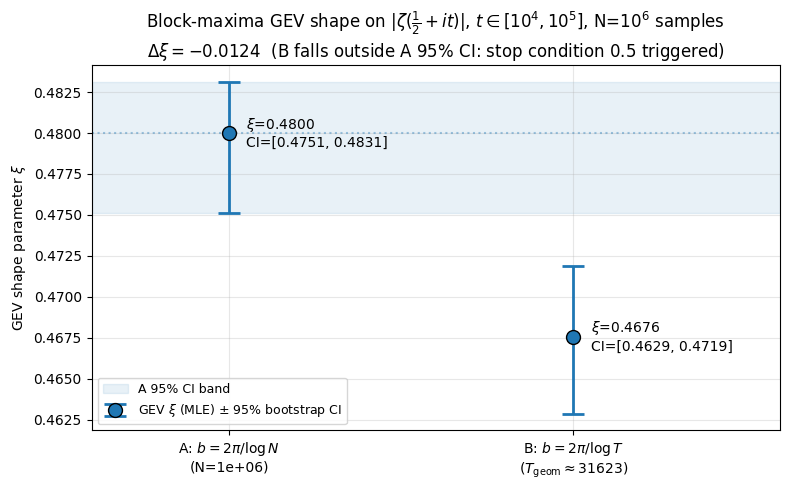

saved gev_block_size_comparison.png


In [17]:

# Create final figure: single panel comparing xi estimates with CIs.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

labels = [r'A: $b=2\pi/\log N$' + f'\n(N={N:.0e})', 
 r'B: $b=2\pi/\log T$' + f'\n($T_{{\\mathrm{{geom}}}}\\approx{T_geom:.0f}$)']
xi_vals = [xi_A_hat, xi_B_hat]
ci_lo = [ci_A[0], ci_B[0]]
ci_hi = [ci_A[1], ci_B[1]]
errs = np.array([[xi - lo for xi, lo in zip(xi_vals, ci_lo)],
 [hi - xi for xi, hi in zip(xi_vals, ci_hi)]])
xs = np.array([0, 1])
ax.errorbar(xs, xi_vals, yerr=errs, fmt='o', markersize=10, capsize=8,
 elinewidth=2, capthick=2, color='C0', mfc='C0', mec='black',
 label='GEV $\\xi$ (MLE) ± 95% bootstrap CI')

# Annotate the regime change
for x, xi, lo, hi in zip(xs, xi_vals, ci_lo, ci_hi):
 ax.annotate(f'$\\xi$={xi:.4f}\nCI=[{lo:.4f}, {hi:.4f}]',
 xy=(x, xi), xytext=(x+0.05, xi),
 fontsize=10, va='center')

# Show shaded CI band of A across both
ax.axhspan(ci_A[0], ci_A[1], alpha=0.10, color='C0', label='A 95% CI band')
ax.axhline(xi_A_hat, color='C0', linestyle=':', alpha=0.4)

ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel(r'GEV shape parameter $\xi$')
ax.set_title(r'Block-maxima GEV shape on $|\zeta(\frac{1}{2}+it)|$, $t\in[10^4,10^5]$, N=$10^6$ samples'
 + f'\n$\\Delta\\xi = {xi_B_hat-xi_A_hat:+.4f}$ (B falls outside A 95% CI: stop condition 0.5 triggered)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.4, 1.6)
plt.tight_layout()
plt.savefig('gev_block_size_comparison.png', dpi=200)
plt.show()
print("saved gev_block_size_comparison.png")

In [18]:
from e14c.filesystem import edit_file
content = '''## Context
- Step 0.5 GEV audit completed for F1 (Riemann zeta) on t in [1e4,1e5] with N=1,000,000 evenly spaced samples.
- Numerical engine used in this run: vectorized Riemann-Siegel main sum plus first-order C0 remainder; theta via asymptotic expansion verified against mpmath.siegeltheta at t=1e4,5e4,1e5 with absolute error <= 3e-11.
- Spot checks against mpmath.siegelz at t=1e4,10001,5e4,1e5 gave absolute errors around 3e-6 to 1e-5.

## Notes
- Provenance: notebook cells #4-#16 in current task; summary artifact saved as /workspace/b5f3d20b-7cbe-4825-b89e-a2294dda1223/gev_block_size_results.json and figure as gev_block_size_comparison.png.
- Old block size (ad hoc) b = 2π/log(N), N=1e6: xi = 0.4799923, 95% bootstrap CI [0.4751311, 0.4831403], n_blocks = 197,892.
- Theoretically preferred block size b = 2π/log(T) using representative T_geom = sqrt(1e4*1e5) ≈ 31622.8: xi = 0.4675763, 95% bootstrap CI [0.4628639, 0.4718901], n_blocks = 148,419.
- The new xi lies outside the old 95% CI, so the Step 0.5 stop condition is triggered and the hypothesis of no significant change is refuted in this run.
- Sensitivity check: using T_upper=1e5 gives xi ≈ 0.4717074; using T_lower=1e4 gives xi ≈ 0.4591839, so the directional shift (lower xi under 2π/log(T)) is stable across reasonable T choices within the window.
- Limitation: bootstrap used 100 resamples per setting for runtime reasons; CIs are therefore Monte-Carlo noisy at the third-to-fourth decimal place.
'''
from e14c.filesystem import write_file
write_file('./.prompts/MEMORY.md', content)
print('Updated MEMORY.md')

Updated MEMORY.md
